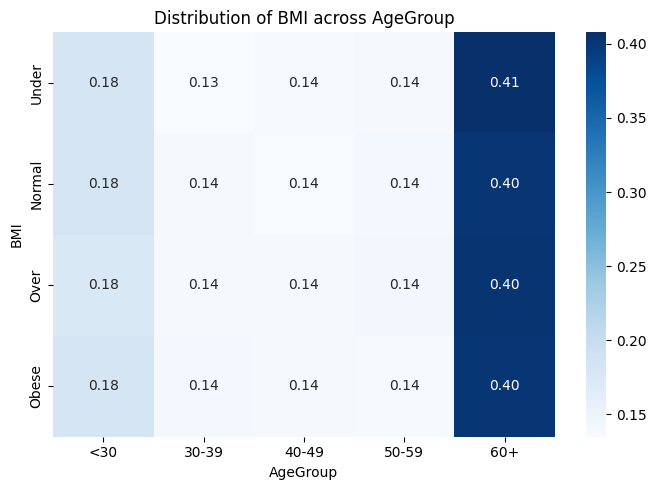

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---- choose or create categorical variables ----
df = pd.read_csv("hypertension_dataset.csv")   # replace with your DataFrame variable

# try to find common columns; fall back to your own
age_col = next((c for c in df.columns if c.lower() in ["age", "age_years"]), None)
bmi_col = next((c for c in df.columns if c.lower() in ["bmi", "body_mass_index"]), None)
activity_col = next((c for c in df.columns if "physical" in c.lower() or "activity" in c.lower()), None)

# pick two categorical variables to cross. If age/bmi are numeric, bin them.
if age_col is not None:
    df["AgeGroup"] = pd.cut(df[age_col], bins=[0, 30, 40, 50, 60, 120], labels=["<30","30-39","40-49","50-59","60+"])
cat_x = "AgeGroup" if "AgeGroup" in df.columns else (activity_col or df.select_dtypes("object").columns[0])

if bmi_col is not None:
    df["BMI"] = pd.cut(df[bmi_col], bins=[0, 18.5, 25, 30, 60], labels=["Under","Normal","Over","Obese"])
cat_y = "BMI" if "BMI" in df.columns else df.select_dtypes("object").columns[1]

# build crosstab and plot
ct = pd.crosstab(df[cat_y], df[cat_x], normalize="index")  # row-normalized
plt.figure(figsize=(7,5))
ax = sns.heatmap(ct, cmap="Blues", annot=True, fmt=".2f")
ax.set_title(f"Distribution of {cat_y} across {cat_x}")
ax.set_xlabel(cat_x)
ax.set_ylabel(cat_y)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

        High       0.72      1.00      0.84     25157
         Low       0.00      0.00      0.00      9840

    accuracy                           0.72     34997
   macro avg       0.36      0.50      0.42     34997
weighted avg       0.52      0.72      0.60     34997



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

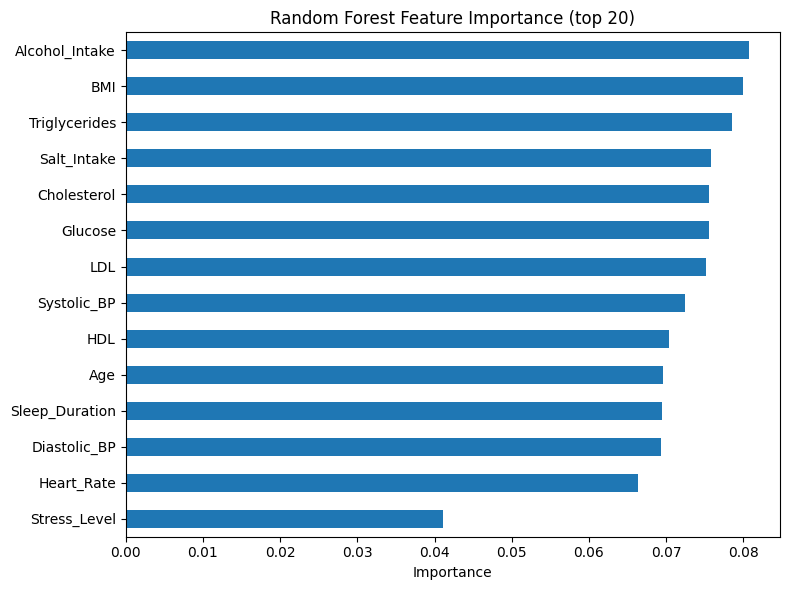

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

df = pd.read_csv("hypertension_dataset.csv")
y_col = next((c for c in df.columns if c.lower() in ["hypertension","htn","target","label"]), None)
if y_col is None:
    raise ValueError("Set y_col to your target column.")

# pick features: numeric only to keep it simple here
X = df.select_dtypes(include=[np.number]).drop(columns=[y_col], errors="ignore")
y = df[y_col]

# drop rows with NaNs (or impute if you prefer)
mask = X.notnull().all(axis=1) & y.notnull()
X, y = X[mask], y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print(classification_report(y_test, rf.predict(X_test)))

# feature importance
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)

plt.figure(figsize=(8,6))
imp.iloc[::-1].plot(kind="barh")
plt.title("Random Forest Feature Importance (top 20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


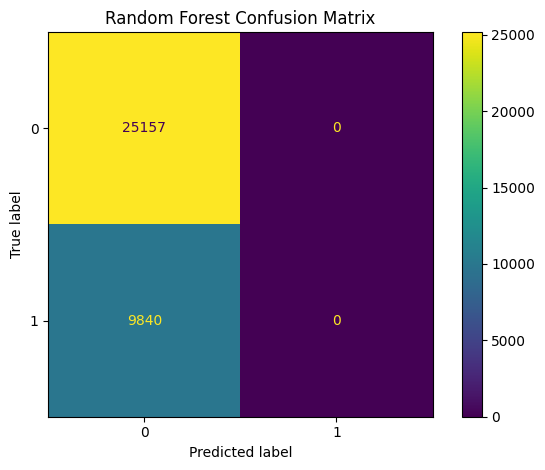

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

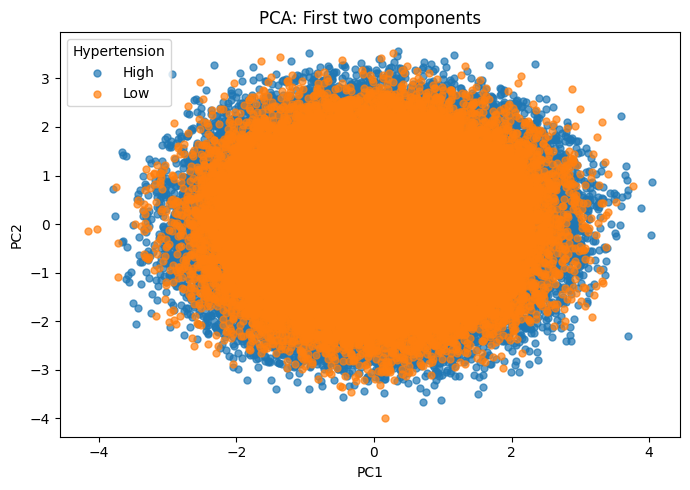

Explained variance ratio: [0.07261993 0.0721946 ]


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv("hypertension_dataset.csv")

# target column guess
y_col = next((c for c in df.columns if c.lower() in ["hypertension","htn","target","label"]), None)
if y_col is None:
    raise ValueError("Could not find a hypertension label column. Set y_col to your target name.")

# choose numeric features only, drop target
X = df.select_dtypes(include=[np.number]).drop(columns=[y_col], errors="ignore").dropna(axis=0)
y = df.loc[X.index, y_col]

# scale, run PCA
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)

# plot
plt.figure(figsize=(7,5))
for cls in np.unique(y):
    idx = (y == cls)
    plt.scatter(pcs[idx,0], pcs[idx,1], s=25, alpha=0.7, label=str(cls))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: First two components")
plt.legend(title=y_col)
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
